In [7]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
#import libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [9]:
import warnings #don't ignore warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("heart_disease_uci.csv") #upload dataset
display(df)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [11]:
df = df.drop(columns=["id"]) #dropping the id column

In [12]:
df.info() #Show general dataset information.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [13]:
describe = df.describe()  #Gives the statistics of the numerical values in the dataframe.
describe 

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [14]:
#Selects the numerical columns in the DataFrame and converts them into a list.
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist() 
numerical_features

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

<Figure size 640x480 with 0 Axes>

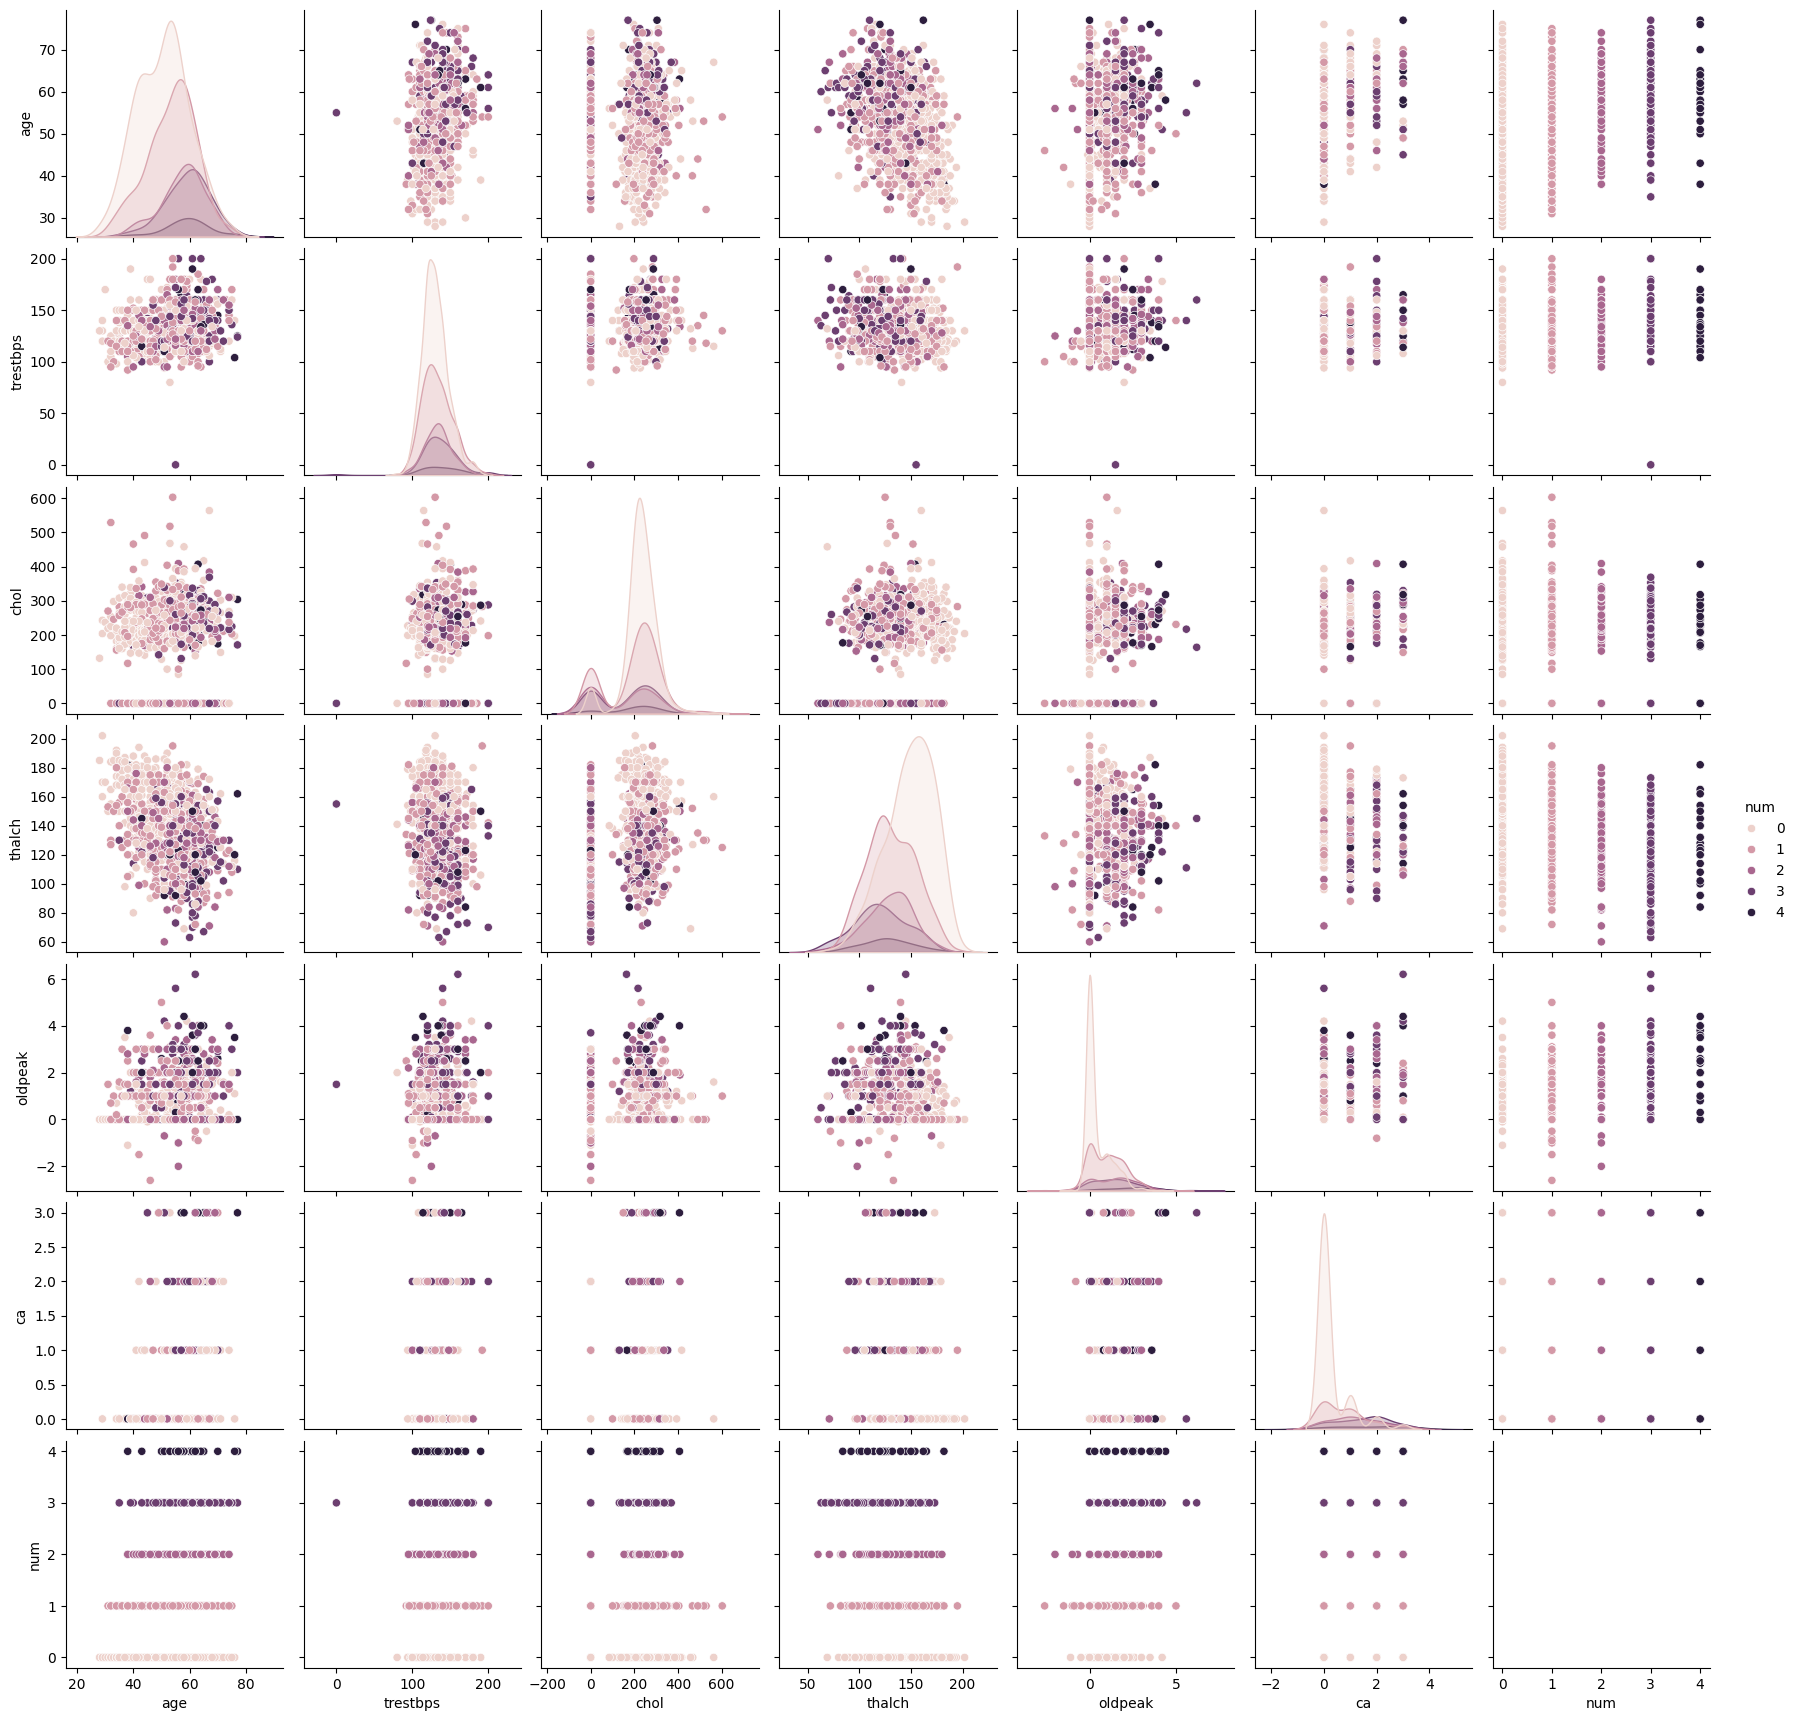

In [15]:
plt.figure() #It is used to plot multiple graphs.
#Gives the relationship between all numerical columns in the dataset. `hue` ensures that the outcomes are marked separately.
#`vars` selects the columns to be visualized.
sns.pairplot(df,vars=numerical_features,hue="num")
plt.show()

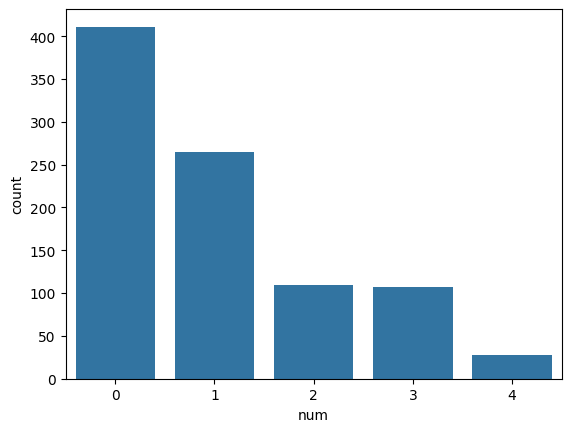

In [16]:
plt.figure()
sns.countplot(x= "num", data = df)
plt.show()

In [17]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [18]:
df= df.drop(columns=["ca"])
df
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
thal        486
num           0
dtype: int64

In [19]:
df["trestbps"].fillna(df["trestbps"].median(),inplace=True)
df["chol"].fillna(df["chol"].median(),inplace=True) 
df["fbs"].fillna(df["fbs"].mode()[0],inplace=True) 
df["restecg"].fillna(df["restecg"].mode()[0],inplace=True)
df["thalch"].fillna(df["thalch"].median(),inplace=True)
df["exang"].fillna(df["exang"].mode()[0],inplace=True) 
df["oldpeak"].fillna(df["oldpeak"].median(),inplace=True)
df["slope"].fillna(df["slope"].mode()[0],inplace=True) 
df["thal"].fillna(df["thal"].mode()[0],inplace=True) 

In [20]:
df.isnull().sum()
display(df)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,flat,normal,1
916,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,flat,normal,0
917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,flat,fixed defect,2
918,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,flat,normal,0


In [21]:
X = df.drop(["num"],axis = 1)
y= df["num"]
display(X)
display(y)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,flat,normal
916,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,flat,normal
917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,flat,fixed defect
918,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,flat,normal


0      0
1      2
2      1
3      0
4      0
      ..
915    1
916    0
917    2
918    0
919    1
Name: num, Length: 920, dtype: int64

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [23]:
categorical_features = ["sex","dataset","cp","restecg","exang","slope","thal"]
numerical_features = ["age","trestbps","chol","fbs","thalch","oldpeak"]

In [24]:
X_train_num = X_train[numerical_features]
X_test_num = X_test[numerical_features]

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.fit_transform(X_test_num)



In [25]:
encoder = OneHotEncoder(sparse_output= False,drop="first")
X_train_cat = X_train[categorical_features]
X_test_cat = X_test[categorical_features]

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.fit_transform(X_test_cat)
X_train_cat_encoded

array([[1., 0., 1., ..., 0., 0., 1.],
       [1., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.]], shape=(690, 14))

In [28]:
X_train_transformed = np.hstack((X_train_num_scaled,X_train_cat_encoded))
X_test_transformed = np.hstack((X_test_num_scaled,X_test_cat_encoded))

In [33]:
print(X_test_transformed)

[[-1.71252607 -0.73116535 -0.35888473 ...  0.          1.
   0.        ]
 [-0.80843809  0.37483945  0.1834878  ...  0.          1.
   0.        ]
 [-0.50707543  1.48084425  1.16536909 ...  0.          1.
   0.        ]
 ...
 [ 1.50200896  0.59604041 -0.10640097 ...  0.          0.
   1.        ]
 [ 0.99973787 -0.17816295 -1.9111923  ...  0.          1.
   0.        ]
 [ 0.49746677  0.15363849  1.07185659 ...  1.          1.
   0.        ]]


In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state= 42)
knn = KNeighborsClassifier()

voting = VotingClassifier(estimators=[("rf",rf),("knn",knn)],voting="soft")


In [37]:
voting.fit(X_train_transformed,y_train)
y_pred = voting.predict(X_test_transformed)

In [38]:
print("Accuracy", accuracy_score(y_test,y_pred))
print("Confusion Matrix:")
cm = confusion_matrix(y_test,y_pred)
print("Classification Report")
print(classification_report(y_test,y_pred))

Accuracy 0.5565217391304348
Confusion Matrix:
Classification Report
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        96
           1       0.48      0.52      0.50        64
           2       0.33      0.26      0.29        31
           3       0.33      0.25      0.29        32
           4       0.00      0.00      0.00         7

    accuracy                           0.56       230
   macro avg       0.37      0.37      0.37       230
weighted avg       0.52      0.56      0.53       230



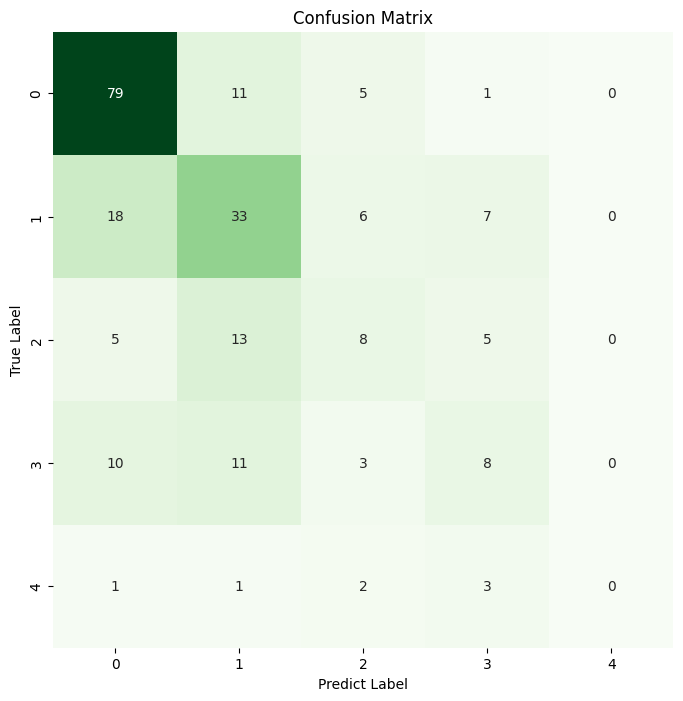

In [43]:
plt.figure(figsize=(8,8))
sns.heatmap(cm,annot=True,fmt="d", cmap="Greens",cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predict Label")
plt.ylabel("True Label")
plt.show()